# Explore Cell Painting channel pseudocoloring

Sample 10 JUMP crops (same seed / selection logic as the attention-map scripts)
and experiment with LUT color assignments and blending modes.

**Before running:** `set -a; source ../.env; set +a` in the terminal,
or set `PROJECT_ROOT`, `CROP_ROOT`, and `METADATA_ROOT` env vars.

In [57]:
import os
import sys
import random
from glob import glob

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = os.environ["PROJECT_ROOT"]
sys.path.insert(0, PROJECT_ROOT)

from utils.crop_loader import load_crop, select_channels
from utils.metadata import load_plate_info, load_well_compound_map

## Configuration

Change `CHANNEL_COLORS` and `BLEND_MODE` here, then re-run the plot cell.

In [58]:
# All 5 Cell Painting channels
CHANNELS = ["DNA", "RNA", "ER", "AGP", "Mito"]

# Map each channel to a LUT color file name (see utils/colormaps/*.lut)
# Available LUTs: blue, cyan, green, light_blue, magenta, orange, pink, red, white, yellow
#                 01_Nucleus_DAPI, 02_Actin_Phalloidin, 03_ER_ConA, 04_RNA_SYTO, 05_Mito_WGA

CHANNEL_COLORS = {
    "DNA": "01_Nucleus_DAPI",
    "AGP": "02_Actin_Phalloidin",
    "ER": "03_ER_ConA",
    "RNA": "04_RNA_SYTO",
    "Mito": "05_Mito_WGA"
}

CHANNEL_COLORS = {
    "DNA":  "blue",
    "RNA":  "yellow",
    "ER":   "green",
    "AGP":  "orange",
    "Mito": "red",
}
# How to combine the 5 colored channels into one RGB image:
#   "sum"  - additive (current default in attention-map scripts), clip to 255
#   "mean" - average, reduces overall brightness
#   "max"  - maximum projection, no clipping needed
BLEND_MODE = "max"

# Sampling — matches attention-map scripts exactly when SEED and CELL_TYPE agree
# (default 8 poscon + 1 DMSO = 9 cells).
SEED = 0
CELL_TYPE = "A549"   # "A549" or "U2OS"
N_POSCON = 8          # 8 poscon + 1 DMSO = 9 cells (same as attention scripts)
CROP_SIZE = 192       # native crop resolution

## Helpers

In [59]:
LUT_DIR = os.path.join(PROJECT_ROOT, "utils", "colormaps")


def load_lut(color_name: str) -> np.ndarray:
    """Load a (1, 256, 3) uint8 LUT array for cv2.LUT."""
    lut = np.array(
        pd.read_csv(os.path.join(LUT_DIR, f"{color_name}.lut"),
                     sep="\t", index_col="Index")
    )[None, ...].astype(np.uint8)
    return lut


def apply_lut(gray: np.ndarray, lut: np.ndarray) -> np.ndarray:
    """Apply a LUT to a single-channel uint8 image. Returns (H, W, 3) uint8."""
    rgb_in = gray[..., None].repeat(3, axis=-1)
    return cv2.LUT(rgb_in, lut)


def build_composite(img_uint8: np.ndarray, color_names: list[str],
                    blend_mode: str = "sum") -> np.ndarray:
    """
    Pseudocolor composite from (H, W, C) uint8.

    blend_mode: 'sum' (additive, clip 255), 'mean', 'max'
    """
    colored = []
    for i, color in enumerate(color_names):
        lut = load_lut(color)
        colored.append(apply_lut(img_uint8[..., i], lut).astype(np.float32))

    stack = np.stack(colored, axis=0)  # (C, H, W, 3)

    if blend_mode == "sum":
        out = np.sum(stack, axis=0).clip(0, 255)
    elif blend_mode == "mean":
        out = np.mean(stack, axis=0).clip(0, 255)
    elif blend_mode == "max":
        out = np.max(stack, axis=0)
    else:
        raise ValueError(f"Unknown blend_mode: {blend_mode}")

    return out.astype(np.uint8)


# ── Cell selection (verbatim from attention-map scripts) ──────────────
def pick_compounds(well_map, n_poscon, rng, override=None):
    poscon = well_map[well_map["control_type"].str.startswith("poscon", na=False)]
    poscon = poscon.drop_duplicates("compound")
    if override:
        chosen = poscon[poscon["compound"].isin(override)]
        missing = set(override) - set(chosen["compound"])
        if missing:
            raise ValueError(f"Requested compounds not found: {missing}")
        chosen = chosen.set_index("compound").loc[override].reset_index()
    else:
        chosen = poscon.sample(n=min(n_poscon, len(poscon)), random_state=rng)
    rows = list(zip(chosen["compound"], chosen["control_type"]))
    rows.append(("DMSO", "negcon"))
    return rows


def find_crop_for_compound(compound, well_map, plates, crop_root, rng):
    wells = well_map.loc[well_map["compound"] == compound, "well"].tolist()
    rng.shuffle(wells)
    for well in wells:
        plate_order = list(plates)
        rng.shuffle(plate_order)
        for plate in plate_order:
            paths = glob(os.path.join(crop_root, plate, well, "*", "crops", "*.png"))
            if paths:
                return str(rng.choice(paths)), plate, well
    raise RuntimeError(f"No crops found for compound '{compound}'")

## Sample crops

In [60]:
rng = np.random.default_rng(SEED)
random.seed(SEED)

plate_info = load_plate_info()
plates = plate_info.loc[plate_info["cell_type"] == CELL_TYPE, "plate"].tolist()
print(f"{CELL_TYPE}: {len(plates)} plates")

well_map = load_well_compound_map()
compound_rows = pick_compounds(well_map, N_POSCON, rng)

crop_root = os.environ["CROP_ROOT"]
samples = []
raw_crops = []
for compound, ctrl_type in compound_rows:
    path, plate, well = find_crop_for_compound(compound, well_map, plates, crop_root, rng)
    samples.append(dict(compound=compound, ctrl_type=ctrl_type, plate=plate, well=well))
    raw_crops.append(load_crop(path, crop_size=CROP_SIZE))
    print(f"  {compound:<20s} [{ctrl_type:<15s}] {plate}/{well}")

print(f"\nLoaded {len(raw_crops)} crops")

A549: 8 plates
  aminopurvalanol-a    [poscon_orf     ] BR00116993/K03
  PF-04217903          [poscon_cp      ] BR00117019/D07
  CYT-997              [poscon_diverse ] BR00117019/C09
  azacitidine          [poscon_diverse ] BR00117016/H05
  EI1                  [poscon_cp      ] BR00116992/E22
  ZK-93423             [poscon_diverse ] BR00116993/E20
  KG-5                 [poscon_cp      ] BR00117015/C13
  AZD7762              [poscon_diverse ] BR00117017/I05
  DMSO                 [negcon         ] BR00116994/I02

Loaded 9 crops


## Plot: composite + individual channels

Re-run this cell after changing `CHANNEL_COLORS` or `BLEND_MODE` above.

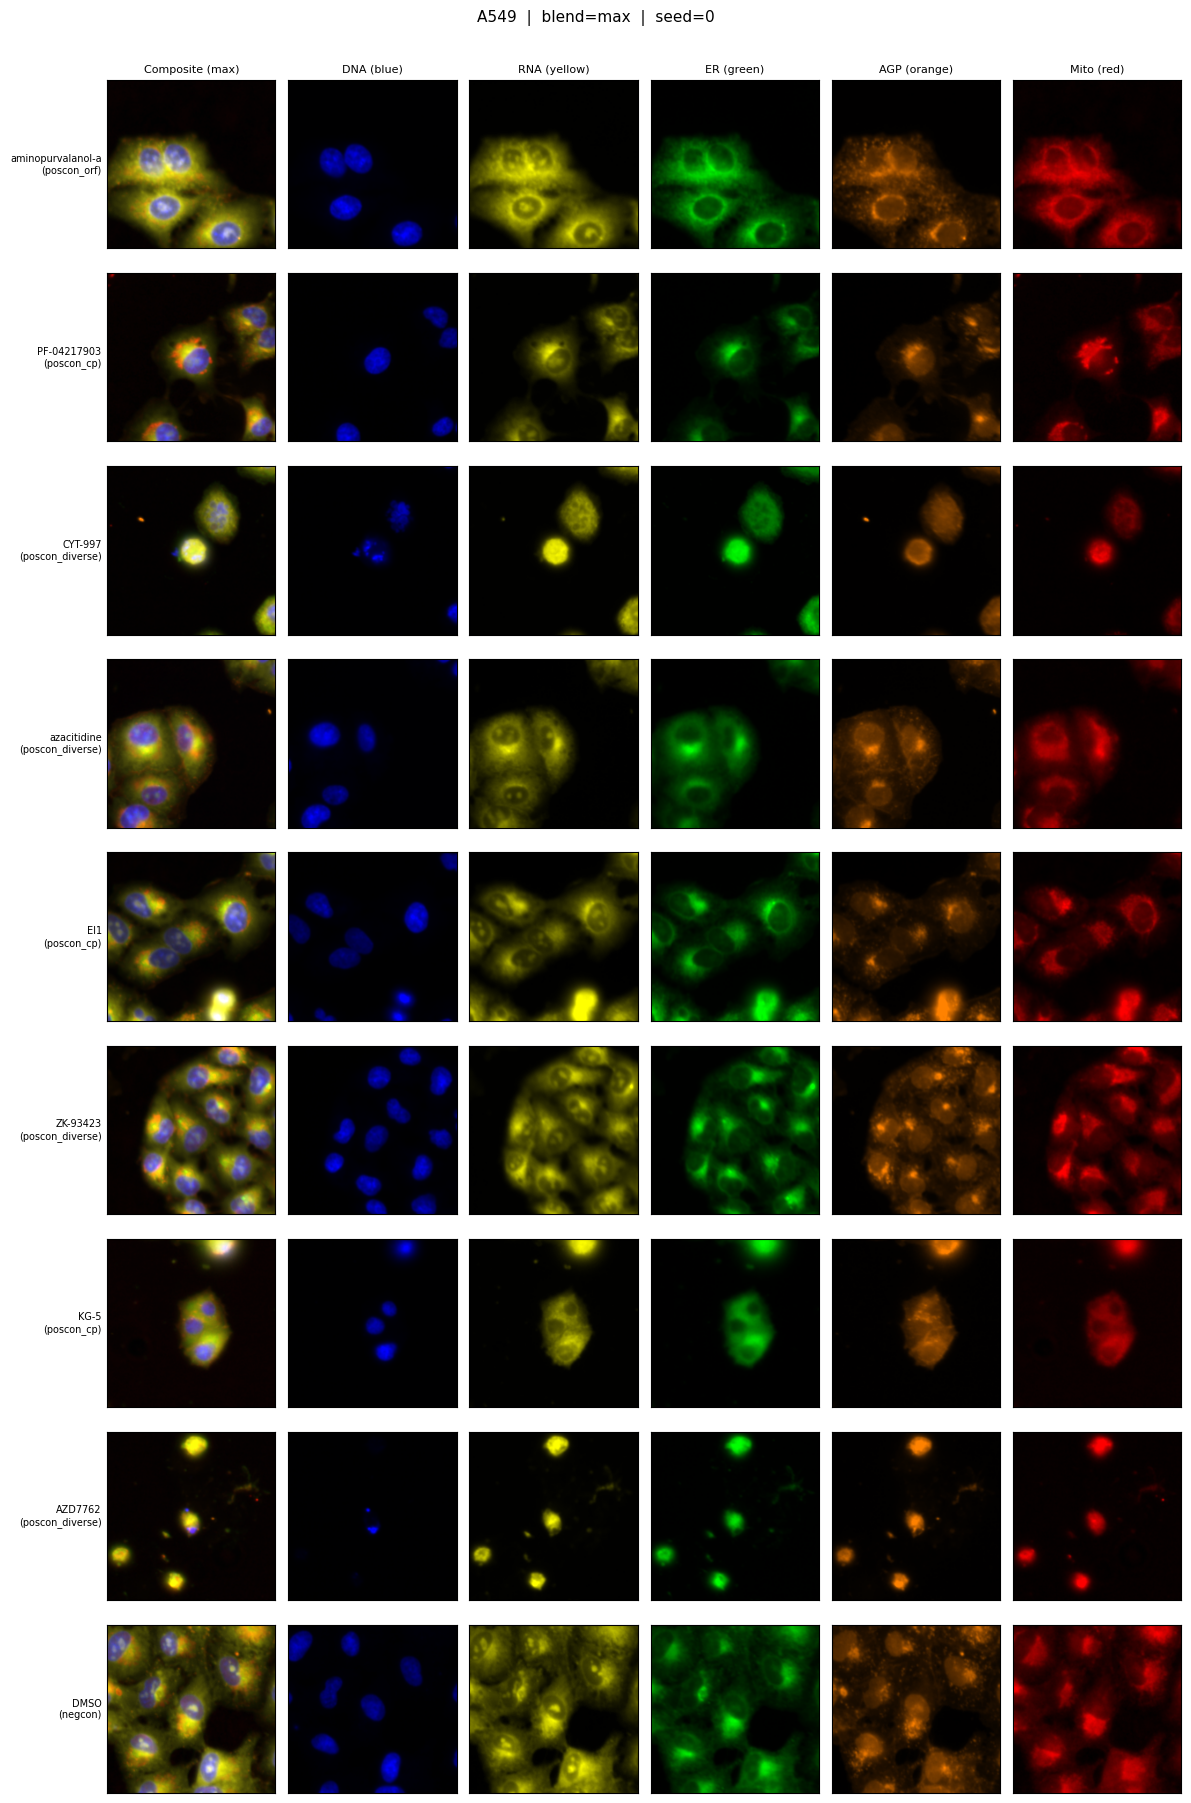

In [61]:
n_images = len(samples)
color_names = [CHANNEL_COLORS[ch] for ch in CHANNELS]
n_ch = len(CHANNELS)

fig, axes = plt.subplots(n_images, n_ch + 1,
                         figsize=((n_ch + 1) * 2, n_images * 2))

for r in range(n_images):
    # Select channels and normalise to uint8
    img_sel = select_channels(raw_crops[r], CHANNELS).transpose(1, 2, 0)  # (H, W, C)
    mn = img_sel.min(axis=(0, 1), keepdims=True)
    mx = img_sel.max(axis=(0, 1), keepdims=True)
    img_u8 = ((img_sel - mn) / (mx - mn + 1e-8) * 255).clip(0, 255).astype(np.uint8)

    # Composite
    composite = build_composite(img_u8, color_names, BLEND_MODE)
    axes[r, 0].imshow(composite)
    axes[r, 0].set_ylabel(
        f"{samples[r]['compound']}\n({samples[r]['ctrl_type']})",
        fontsize=7, rotation=0, ha="right", va="center")
    if r == 0:
        axes[r, 0].set_title(f"Composite ({BLEND_MODE})", fontsize=8)

    # Individual channels, each in its own LUT color
    for c in range(n_ch):
        lut = load_lut(color_names[c])
        ch_img = apply_lut(img_u8[..., c], lut)
        axes[r, 1 + c].imshow(ch_img)
        if r == 0:
            axes[r, 1 + c].set_title(f"{CHANNELS[c]} ({color_names[c]})", fontsize=8)

    for ax in axes[r]:
        ax.set_xticks([])
        ax.set_yticks([])

plt.suptitle(
    f"{CELL_TYPE}  |  blend={BLEND_MODE}  |  seed={SEED}",
    fontsize=11, y=1.002)
plt.tight_layout()
plt.show()